# Importación de librerías

In [1]:
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import filters_and_features as ff
import data_processor as dp
import numpy as np
from sklearn.decomposition import PCA

# Importación de datos

In [2]:
df = dp.lectura(mode=3) # Leyendo 3 primeros individuos
df_val = dp.lectura(mode=4) # Leyendo 10mo individuo

Se crea el dataframe df_block

In [3]:
df_block = dp.create_df_block(df)
df_block_val = dp.create_df_block(df_val)

In [4]:
del df
del df_val

Se limpia y visualiza el contenido

In [5]:
dp.balance(df_block)
dp.balance(df_block_val)
print(df_block['stimulus'].value_counts())
print(df_block_val['stimulus'].value_counts())

stimulus
1     348
0     348
3     348
4     348
6     348
9     348
10    348
11    348
Name: count, dtype: int64
stimulus
1     72
3     72
0     72
4     72
6     72
9     72
10    72
11    72
Name: count, dtype: int64


# Filtro

In [6]:
df_block_filtered = dp.filter(df_block)
df_block_filtered_val = dp.filter(df_block_val)

Procesando: 100%|██████████| 3/3 [01:11<00:00, 23.80s/it]


In [7]:
del df_block
del df_block_val

# Extracción de características

In [12]:
scaler, df_block_features = dp.get_carac(df_block_filtered)
df_block_features_val = dp.get_carac(df_block_filtered_val, scaler)

Extrayendo Características: 100%|██████████| 576/576 [03:25<00:00,  2.80it/s]


In [13]:
del df_block_filtered
del df_block_filtered_val

In [14]:
df_block_features.describe()

,fft_1,psd_1,mf_1,mdf_1,zc_1,ssc_1,df_1,sk_1,br_1,fft_2,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
count,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.00000,2784.000000,2784.000000,2784.000000,2784.000000,...,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000
mean,54.352597,0.001044,204.497534,76.918463,1489.622126,2449.37967,123.517093,3.727590,0.095104,49.403895,...,55.445480,0.001016,211.334777,73.643678,1778.974138,2901.411997,105.862130,5.720343,0.171135,5.500000
std,3.814880,0.000043,20.335839,17.049214,222.007742,280.66875,52.568928,1.492151,0.028709,3.520690,...,6.898377,0.000055,39.608696,33.820501,505.335280,489.798887,80.142753,6.246005,0.124192,3.905826
min,40.632754,0.000141,155.065811,21.000000,668.000000,1506.00000,17.299662,0.869391,0.040273,37.302967,...,25.931755,0.000509,70.074947,10.000000,112.000000,1345.000000,17.109145,0.434102,0.076999,0.000000
25%,52.315922,0.001021,190.269955,64.000000,1370.000000,2323.00000,86.868450,2.611137,0.075214,47.642517,...,50.954683,0.000988,178.602963,45.000000,1406.000000,2574.000000,40.635264,1.101846,0.098390,2.500000
50%,54.712381,0.001043,201.546523,74.000000,1499.000000,2478.00000,111.961123,3.532832,0.093003,49.738279,...,54.667595,0.001009,197.994846,58.000000,1606.000000,2768.000000,74.124982,4.895672,0.141831,5.000000
75%,56.964354,0.001068,215.039789,87.000000,1641.000000,2639.00000,150.295763,4.640342,0.110193,51.686840,...,61.939834,0.001037,253.770620,113.000000,2330.000000,3357.000000,148.952219,7.929020,0.205824,9.250000
max,63.137331,0.001229,272.162934,128.000000,2156.000000,3200.00000,341.689696,16.125272,0.509728,61.938036,...,67.207772,0.001394,282.883309,123.000000,2696.000000,3920.000000,420.000000,63.151246,2.267337,11.000000


In [15]:
df_block_features_val.describe()

,fft_1,psd_1,mf_1,mdf_1,zc_1,ssc_1,df_1,sk_1,br_1,fft_2,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,...,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,53.732137,0.001044,202.053769,76.406250,1432.220486,2392.970486,121.140865,5.035348,0.121802,50.644607,...,62.033852,0.000989,254.863431,113.203125,2345.979167,3364.184028,180.926023,1.085112,0.098086,5.500000
std,5.315689,0.000038,23.264867,17.243269,214.313444,263.543764,49.585323,8.640254,0.185590,3.891944,...,3.167300,0.000022,3.171787,2.171449,250.502541,326.519198,70.603591,0.302276,0.007497,3.908519
min,25.478585,0.000827,94.188979,11.000000,734.000000,1609.000000,17.052375,1.466331,0.040984,34.470110,...,51.648754,0.000890,244.878890,105.000000,1368.000000,2332.000000,19.866120,0.490639,0.082833,0.000000
25%,52.587769,0.001024,192.526847,68.000000,1322.750000,2302.750000,86.537183,2.884756,0.073458,48.204132,...,61.484171,0.000976,252.872871,112.000000,2285.750000,3288.000000,147.307767,0.873250,0.093148,2.500000
50%,54.864677,0.001042,201.645132,75.500000,1457.500000,2419.000000,118.884012,3.491389,0.088989,51.708441,...,62.556781,0.000989,254.540678,113.000000,2387.500000,3396.000000,217.548248,1.038929,0.096876,5.000000
75%,56.761748,0.001061,215.192599,87.000000,1572.250000,2584.500000,150.232394,4.351705,0.106678,53.400222,...,64.245432,0.001003,256.481302,114.000000,2542.250000,3603.000000,223.003354,1.253361,0.101849,9.250000
max,61.048499,0.001228,252.679595,112.000000,1942.000000,2907.000000,289.726095,71.538610,1.534903,59.456888,...,66.506907,0.001056,271.744582,121.000000,2670.000000,3830.000000,413.109099,2.568017,0.143437,11.000000


# Normalización

In [16]:
scaler, df_block_normalized = dp.normalize(df_block_features)
df_block_normalized_val = dp.normalize(df_block_features_val, scaler)

In [17]:
del df_block_features
del df_block_features_val

In [18]:
df_block_normalized.describe()

,fft_1,psd_1,mf_1,mdf_1,zc_1,ssc_1,df_1,sk_1,br_1,fft_2,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
count,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2784.000000,2.784000e+03,2.784000e+03,2.784000e+03,...,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2784.000000
mean,-2.041789e-16,-2.986117e-15,8.167158e-17,3.675221e-16,-8.167158e-17,4.083579e-16,0.000000,1.633432e-16,2.858505e-16,-2.450147e-16,...,-8.167158e-17,1.235283e-15,-4.900295e-16,1.225074e-16,1.633432e-16,8.167158e-17,-1.225074e-16,1.225074e-16,5.104474e-17,5.500000
std,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180,1.000180e+00,1.000180e+00,1.000180e+00,...,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,3.905826
min,-3.597048e+00,-2.089095e+01,-2.431205e+00,-3.280416e+00,-3.701536e+00,-3.361789e+00,-2.020899,-1.915833e+00,-1.910227e+00,-3.437708e+00,...,-4.279127e+00,-9.230287e+00,-3.567025e+00,-1.882146e+00,-3.299341e+00,-3.178226e+00,-1.107635e+00,-8.464915e-01,-7.581179e-01,0.000000
25%,-5.339724e-01,-5.275047e-01,-6.997564e-01,-7.578521e-01,-5.389164e-01,-4.503614e-01,-0.697279,-7.483512e-01,-6.929428e-01,-5.003835e-01,...,-6.511104e-01,-4.967714e-01,-8.265280e-01,-8.470846e-01,-7.382052e-01,-6.685822e-01,-8.140297e-01,-7.395649e-01,-5.858483e-01,2.500000
50%,9.432750e-02,-1.652683e-02,-1.451398e-01,-1.712095e-01,4.224879e-02,1.019902e-01,-0.219865,-1.305448e-01,-7.319711e-02,9.499382e-02,...,-1.127838e-01,-1.219903e-01,-3.368535e-01,-4.626333e-01,-3.423573e-01,-2.724301e-01,-3.960788e-01,-1.320555e-01,-2.360009e-01,5.000000
75%,6.847466e-01,5.543051e-01,5.185008e-01,5.914260e-01,6.819810e-01,6.757232e-01,0.509493,6.118120e-01,5.256669e-01,6.485533e-01,...,9.416013e-01,3.884500e-01,1.071569e+00,1.163891e+00,1.090612e+00,9.303203e-01,5.377633e-01,3.536780e-01,2.793685e-01,9.250000
max,2.303169e+00,4.296084e+00,3.327994e+00,2.996661e+00,3.002137e+00,2.674880e+00,4.150965,8.310088e+00,1.444475e+01,3.560778e+00,...,1.705387e+00,6.885491e+00,1.806709e+00,1.459623e+00,1.815014e+00,2.079978e+00,3.920433e+00,9.196474e+00,1.688176e+01,11.000000


In [19]:
df_block_normalized_val.describe()

,fft_1,psd_1,mf_1,mdf_1,zc_1,ssc_1,df_1,sk_1,br_1,fft_2,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,...,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,-0.162671,-0.004091,-0.120192,-0.030049,-0.258603,-0.201017,-0.045210,0.876582,0.930109,0.352469,...,0.955233,-0.488402,1.099165,1.169899,1.122239,0.944990,0.936796,-0.742245,-0.588297,5.500000
std,1.393660,0.878765,1.144238,1.011564,0.965516,0.939154,0.943413,5.791507,6.465632,1.105648,...,0.459219,0.410044,0.080092,0.064217,0.495805,0.666759,0.881131,0.048404,0.060375,3.908519
min,-7.570146,-5.017334,-5.425317,-3.867058,-3.404196,-2.994743,-2.025604,-1.515708,-1.885467,-4.242484,...,-0.550479,-2.297100,0.847040,0.927306,-0.813416,-1.162751,-1.073228,-0.837438,-0.711138,0.000000
25%,-0.462700,-0.467377,-0.588755,-0.523195,-0.751785,-0.522523,-0.703582,-0.564946,-0.754133,-0.340836,...,0.875536,-0.730151,1.048900,1.134318,1.003031,0.789421,0.517241,-0.776170,-0.628070,2.500000
50%,0.134256,-0.035183,-0.140290,-0.083213,-0.144715,-0.108260,-0.088149,-0.158324,-0.213060,0.654690,...,1.031051,-0.485565,1.091015,1.163891,1.204419,1.009959,1.393840,-0.749640,-0.598046,5.000000
75%,0.631628,0.405625,0.526016,0.591426,0.372252,0.481509,0.508287,0.418340,0.403216,1.135302,...,1.275885,-0.223232,1.140018,1.193465,1.510706,1.432657,1.461920,-0.715303,-0.557990,9.250000
max,1.755522,4.258595,2.369743,2.058033,2.038033,1.630757,3.162303,45.453297,50.159996,2.855917,...,1.603771,0.738842,1.525439,1.400477,1.763554,1.896196,3.834435,-0.504785,-0.223066,11.000000


# Creación de dataframes de entrenamiento y testeo

In [20]:
y = df_block_normalized.iloc[:, -1]
X = df_block_normalized.iloc[:, :-1]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

In [21]:
y_val = df_block_normalized_val.iloc[:, -1]
X_val = df_block_normalized_val.iloc[:, :-1]

In [22]:
del df_block_normalized
del df_block_normalized_val

In [23]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)

(1948, 126) (1948,)
(576, 126) (576,)


# Entrenamiento y testeo del modelo

Importamos librerías

In [24]:
# Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Rotation forest
from sktime.classification.sklearn import RotationForest
from sktime.datasets import load_unit_test
from sktime.datatypes._panel._convert import from_nested_to_3d_numpy

# Artificial Neural Networks (ANN)
import setuptools.dist
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

In [25]:
# Visualization libraries

import seaborn as sns

Random forest

In [26]:
rf = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf.fit(X_train, y_train)
y_pred_RanF = rf.predict(X_test)
y_pred_RanF_val = rf.predict(X_val)

Rotation forest

In [27]:
clf = RotationForest(n_estimators=300)
clf.fit(X_train, y_train)
y_pred_RotF = clf.predict(X_test)
y_pred_RotF_val = clf.predict(X_val)

Artificial Neural Networks (ANN)

In [28]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann = le.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_val = le.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step


# Resultados

Random forest

Test data

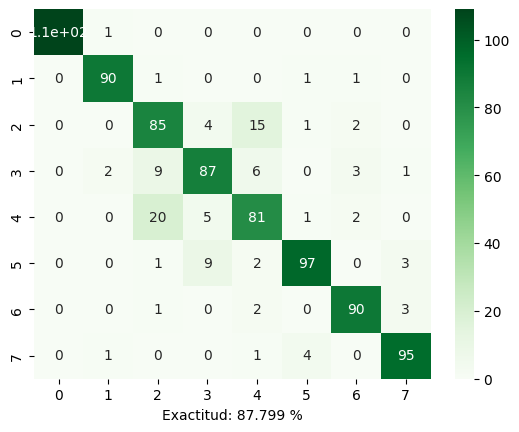

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       110
           1       0.96      0.97      0.96        93
           3       0.73      0.79      0.76       107
           4       0.83      0.81      0.82       108
           6       0.76      0.74      0.75       109
           9       0.93      0.87      0.90       112
          10       0.92      0.94      0.93        96
          11       0.93      0.94      0.94       101

    accuracy                           0.88       836
   macro avg       0.88      0.88      0.88       836
weighted avg       0.88      0.88      0.88       836



In [29]:
sns.heatmap(confusion_matrix(y_pred_RanF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF, y_test))

Validation data

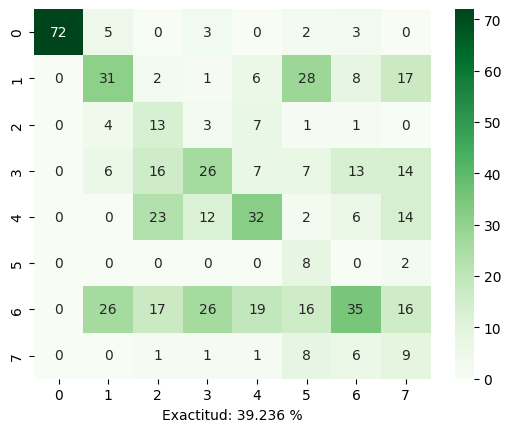

              precision    recall  f1-score   support

           0       1.00      0.85      0.92        85
           1       0.43      0.33      0.38        93
           3       0.18      0.45      0.26        29
           4       0.36      0.29      0.32        89
           6       0.44      0.36      0.40        89
           9       0.11      0.80      0.20        10
          10       0.49      0.23      0.31       155
          11       0.12      0.35      0.18        26

    accuracy                           0.39       576
   macro avg       0.39      0.46      0.37       576
weighted avg       0.49      0.39      0.41       576



In [30]:
sns.heatmap(confusion_matrix(y_pred_RanF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_val, y_val))

Rotation forest

Test data

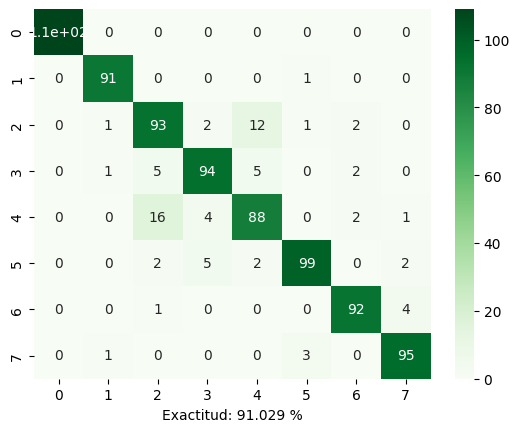

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       0.97      0.99      0.98        92
           3       0.79      0.84      0.82       111
           4       0.90      0.88      0.89       107
           6       0.82      0.79      0.81       111
           9       0.95      0.90      0.93       110
          10       0.94      0.95      0.94        97
          11       0.93      0.96      0.95        99

    accuracy                           0.91       836
   macro avg       0.91      0.91      0.91       836
weighted avg       0.91      0.91      0.91       836



In [31]:
sns.heatmap(confusion_matrix(y_pred_RotF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF, y_test))

Validation data

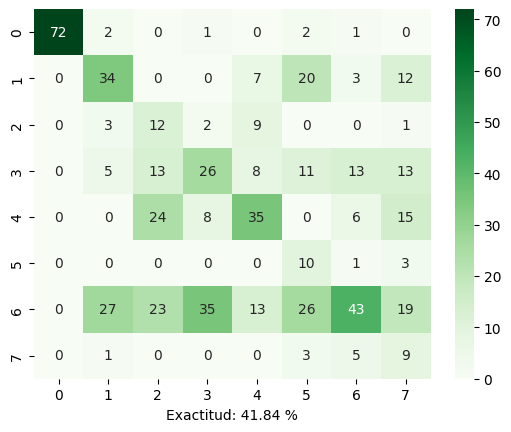

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        78
           1       0.47      0.45      0.46        76
           3       0.17      0.44      0.24        27
           4       0.36      0.29      0.32        89
           6       0.49      0.40      0.44        88
           9       0.14      0.71      0.23        14
          10       0.60      0.23      0.33       186
          11       0.12      0.50      0.20        18

    accuracy                           0.42       576
   macro avg       0.42      0.49      0.40       576
weighted avg       0.54      0.42      0.44       576



In [32]:
sns.heatmap(confusion_matrix(y_pred_RotF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_val, y_val))

Artificial Neural Networks (ANN)

Test data

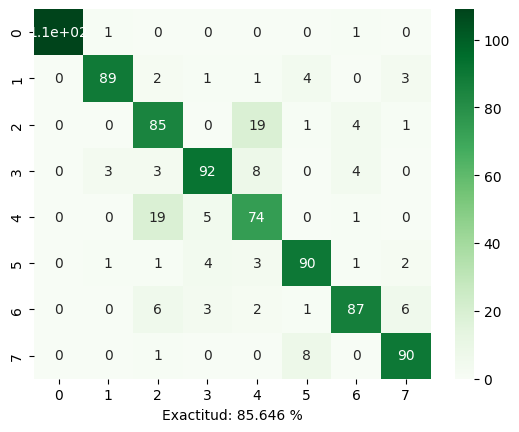

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       111
           1       0.95      0.89      0.92       100
           3       0.73      0.77      0.75       110
           4       0.88      0.84      0.86       110
           6       0.69      0.75      0.72        99
           9       0.87      0.88      0.87       102
          10       0.89      0.83      0.86       105
          11       0.88      0.91      0.90        99

    accuracy                           0.86       836
   macro avg       0.86      0.86      0.86       836
weighted avg       0.86      0.86      0.86       836



In [33]:
sns.heatmap(confusion_matrix(y_pred_ann, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann, y_test))

Validation data

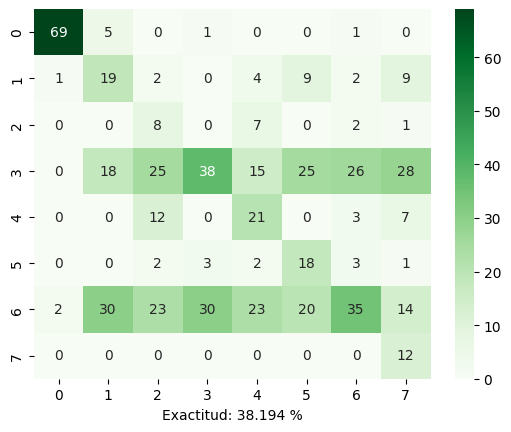

              precision    recall  f1-score   support

           0       0.96      0.91      0.93        76
           1       0.26      0.41      0.32        46
           3       0.11      0.44      0.18        18
           4       0.53      0.22      0.31       175
           6       0.29      0.49      0.37        43
           9       0.25      0.62      0.36        29
          10       0.49      0.20      0.28       177
          11       0.17      1.00      0.29        12

    accuracy                           0.38       576
   macro avg       0.38      0.54      0.38       576
weighted avg       0.50      0.38      0.39       576



In [34]:
sns.heatmap(confusion_matrix(y_pred_ann_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_val, y_val))

# Con PCA

In [35]:
pca = PCA(n_components=0.8)

X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

X_pca_val = pca.transform(X_val)

In [36]:
print('Sin PCA')
print(X.shape)
print(X_pca.shape)
print('Con PCA')
print(X_val.shape)
print(X_pca_val.shape)

Sin PCA
(2784, 126)
(2784, 20)
Con PCA
(576, 126)
(576, 20)


Random forest

In [37]:
rf_pca = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf_pca.fit(X_train_pca, y_train)
y_pred_RanF_pca = rf_pca.predict(X_test_pca)
y_pred_RanF_pca_val = rf_pca.predict(X_pca_val)

Rotation forest

In [38]:
clf_pca = RotationForest(n_estimators=300)
clf_pca.fit(X_train_pca, y_train)
y_pred_RotF_pca = clf_pca.predict(X_test_pca)
y_pred_RotF_pca_val = clf_pca.predict(X_pca_val)

Artificial Neural Networks (ANN)

In [39]:
le_pca = LabelEncoder()
y_train_enc = le_pca.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le_pca.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_pca, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test_pca)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann_pca = le_pca.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_pca_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_pca_val = le_pca.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


# Resultados

Random forest

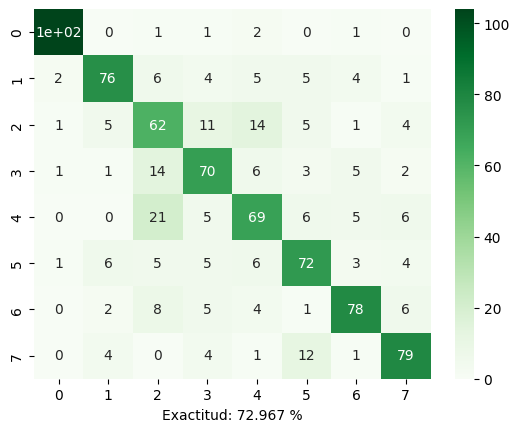

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       109
           1       0.81      0.74      0.77       103
           3       0.53      0.60      0.56       103
           4       0.67      0.69      0.68       102
           6       0.64      0.62      0.63       112
           9       0.69      0.71      0.70       102
          10       0.80      0.75      0.77       104
          11       0.77      0.78      0.78       101

    accuracy                           0.73       836
   macro avg       0.73      0.73      0.73       836
weighted avg       0.73      0.73      0.73       836



In [40]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca, y_test))

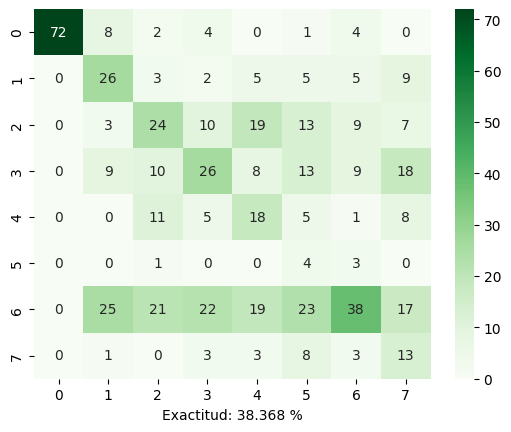

              precision    recall  f1-score   support

           0       1.00      0.79      0.88        91
           1       0.36      0.47      0.41        55
           3       0.33      0.28      0.31        85
           4       0.36      0.28      0.32        93
           6       0.25      0.38      0.30        48
           9       0.06      0.50      0.10         8
          10       0.53      0.23      0.32       165
          11       0.18      0.42      0.25        31

    accuracy                           0.38       576
   macro avg       0.38      0.42      0.36       576
weighted avg       0.48      0.38      0.41       576



In [41]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca_val, y_val))

Rotation forest

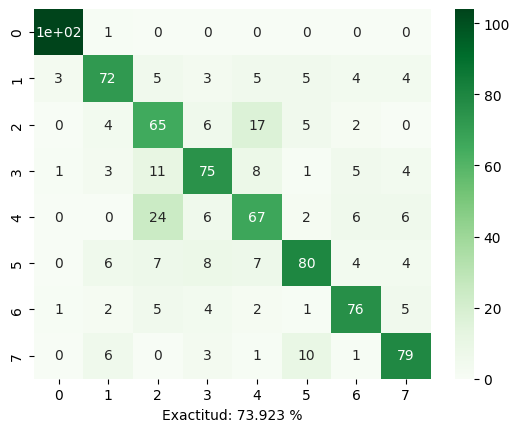

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       105
           1       0.77      0.71      0.74       101
           3       0.56      0.66      0.60        99
           4       0.71      0.69      0.70       108
           6       0.63      0.60      0.61       111
           9       0.77      0.69      0.73       116
          10       0.78      0.79      0.78        96
          11       0.77      0.79      0.78       100

    accuracy                           0.74       836
   macro avg       0.74      0.74      0.74       836
weighted avg       0.74      0.74      0.74       836



In [42]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca, y_test))

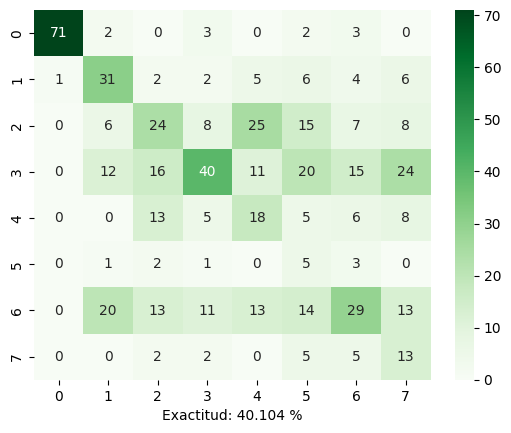

              precision    recall  f1-score   support

           0       0.99      0.88      0.93        81
           1       0.43      0.54      0.48        57
           3       0.33      0.26      0.29        93
           4       0.56      0.29      0.38       138
           6       0.25      0.33      0.28        55
           9       0.07      0.42      0.12        12
          10       0.40      0.26      0.31       113
          11       0.18      0.48      0.26        27

    accuracy                           0.40       576
   macro avg       0.40      0.43      0.38       576
weighted avg       0.48      0.40      0.42       576



In [43]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca_val, y_val))

Artificial Neural Networks (ANN)

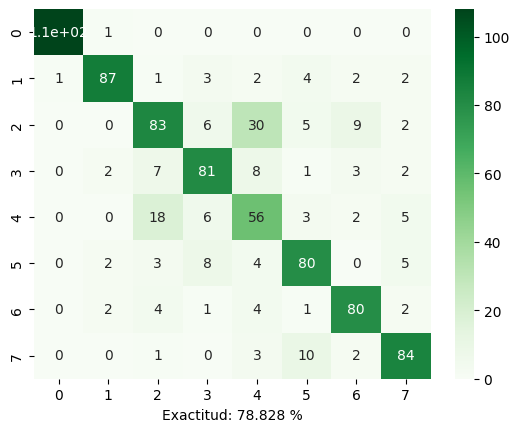

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       109
           1       0.93      0.85      0.89       102
           3       0.71      0.61      0.66       135
           4       0.77      0.78      0.78       104
           6       0.52      0.62      0.57        90
           9       0.77      0.78      0.78       102
          10       0.82      0.85      0.83        94
          11       0.82      0.84      0.83       100

    accuracy                           0.79       836
   macro avg       0.79      0.79      0.79       836
weighted avg       0.79      0.79      0.79       836



In [44]:
sns.heatmap(confusion_matrix(y_pred_ann_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca, y_test))

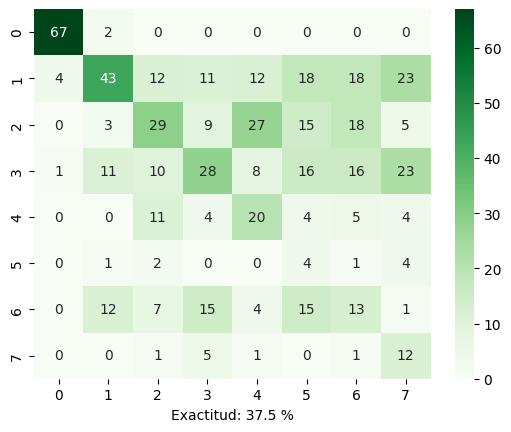

              precision    recall  f1-score   support

           0       0.93      0.97      0.95        69
           1       0.60      0.30      0.40       141
           3       0.40      0.27      0.33       106
           4       0.39      0.25      0.30       113
           6       0.28      0.42      0.33        48
           9       0.06      0.33      0.10        12
          10       0.18      0.19      0.19        67
          11       0.17      0.60      0.26        20

    accuracy                           0.38       576
   macro avg       0.38      0.42      0.36       576
weighted avg       0.46      0.38      0.39       576



In [45]:
sns.heatmap(confusion_matrix(y_pred_ann_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca_val, y_val))

Rpoerte de PCA

In [46]:
X

,fft_1,psd_1,mf_1,mdf_1,zc_1,ssc_1,df_1,sk_1,br_1,fft_2,...,br_13,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14
0,0.259076,0.367947,-0.366947,-0.640524,0.790105,0.779066,-1.207202,0.274207,0.142610,0.656523,...,-0.324491,-0.105075,0.899848,-0.478995,-0.640072,-0.649139,-0.462338,0.054822,0.116107,-0.004973
1,-0.262654,1.094653,-0.010973,-0.112545,0.276517,0.162571,0.036340,0.145564,-0.256015,-0.062073,...,-0.085634,-0.619703,0.799766,-0.687134,-0.492206,-0.858939,-0.956507,-0.281273,-0.143577,-0.219010
2,-0.644907,0.069727,0.109664,-0.347202,-0.327174,-0.842353,-0.391035,-0.288457,0.039940,-0.610411,...,0.086917,-1.251490,3.119380,-0.888681,-0.669645,-1.151866,-1.391458,-0.547724,0.132098,-0.070303
3,0.167210,0.711260,-0.442522,-0.699188,0.844167,0.786194,-0.422542,1.294703,-0.197338,0.724074,...,-0.206792,-0.058645,1.252927,-0.509101,-0.610499,-0.575908,-0.378615,-0.907962,-0.096875,0.000370
4,-0.440056,0.571902,-0.493313,-0.581859,0.249486,-0.154586,-0.615498,0.716618,0.004190,-0.207711,...,-0.003160,-0.460816,0.209817,-0.621902,-0.462633,-0.912378,-0.917709,-1.013581,-0.037743,0.017185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2779,-0.095345,1.198257,-0.395142,-0.816516,-0.714618,0.166134,-0.114319,-0.093081,1.226735,0.514271,...,0.340553,0.912191,-0.860554,1.060584,1.193465,1.203429,0.787379,1.462262,-0.766304,-0.587411
2780,-0.098696,0.664328,-0.794726,-1.696480,-0.318164,0.034283,-1.658459,2.053847,1.710340,0.225498,...,-0.145797,1.239759,-0.434771,1.051784,1.134318,1.664592,1.371397,2.383970,-0.644390,-0.609975
2781,0.307856,0.902480,0.117814,-0.816516,-0.264102,0.504672,-1.548946,-0.219416,0.995275,0.143625,...,-0.054293,0.865955,-0.504791,1.101465,1.163891,1.217284,0.758791,2.383691,-0.615129,-0.646275
2782,0.463701,0.435995,-0.181212,-0.757852,-0.687587,-0.535887,-1.226886,0.496779,0.710421,0.283543,...,-0.241027,1.281118,-0.322987,0.990498,1.193465,1.492398,1.412237,1.440946,-0.773051,-0.513434
